In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_cpu = pd.read_json("results/run_10_cpu.json")[1:]
data_cpu.loc[data_cpu.index[:30], "device_count"] = 0

data_gpu = pd.read_json("results/run_10_cuda.json")
data_gpu.loc[data_gpu.index[:30], "device_count"] = 0

data_cpu_100 = pd.read_json("results/run_100_cpu.json")
data_cpu_100.loc[data_cpu_100.index[:300], "device_count"] = 0

# Add a column to distinguish CPU and GPU runs
data_cpu["device_type"] = "cpu"
data_gpu["device_type"] = "gpu"
data_cpu_100["device_type"] = "cpu_100"

# Concatenate both DataFrames into a single table
data = pd.concat([data_cpu, data_gpu, data_cpu_100], ignore_index=True)

# Show the first few rows of the merged table
data.groupby(["device_type", "device_count"]).size().reset_index(name="count")

,device_type,device_count,count
0,cpu,0,30
1,cpu,1,30
2,cpu,2,30
3,cpu,4,30
4,cpu,8,30
5,cpu,16,30
6,cpu,32,30
7,cpu_100,0,300
8,cpu_100,1,300
9,gpu,0,30


In [3]:
def runtime_by_device_count(df: pd.DataFrame, title: str) -> None:
    # Aggregate mean and standard deviation of runtime by prompt length and device count
    stats = (
        df.groupby(["prompt_length", "device_count"], as_index=False)["time"]
            .agg(mean="mean", std="std")
    )
    stats["std"] = stats["std"].fillna(0.0)

    plt.style.use("bmh")
    lengths = list(stats["prompt_length"].unique())
    cmap = plt.get_cmap("tab10")
    markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]
    xticks = sorted(stats["device_count"].unique())

    for i, length in enumerate(lengths):
        grp = stats[stats["prompt_length"] == length].sort_values("device_count")
        color = cmap(i % 10)
        fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
        ax.plot(
            grp["device_count"], grp["mean"],
            color=color, marker=markers[i % len(markers)],
            linewidth=2, markersize=6, label=f"Prompt length {length}",
        )
        ax.fill_between(
            grp["device_count"],
            grp["mean"] - grp["std"],
            grp["mean"] + grp["std"],
            color=color, alpha=0.18, linewidth=0,
        )
        ax.set_xticks(xticks)
        ax.set_xlim(min(xticks) - 0.25, max(xticks) + 0.25)
        ax.set_xlabel("Device count")
        ax.set_ylabel("Runtime (s)")
        ax.set_title(f"Runtime by device count (Prompt length: {length}) - " + title)
        ax.grid(which="major", alpha=0.35)
        ax.minorticks_on()
        ax.grid(which="minor", alpha=0.15, linestyle="--")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.legend(frameon=True, fancybox=True, framealpha=0.9)
        plt.show()

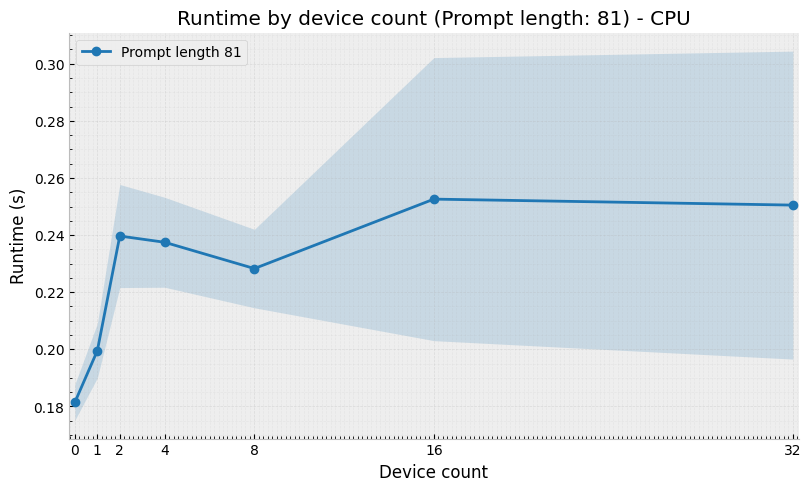

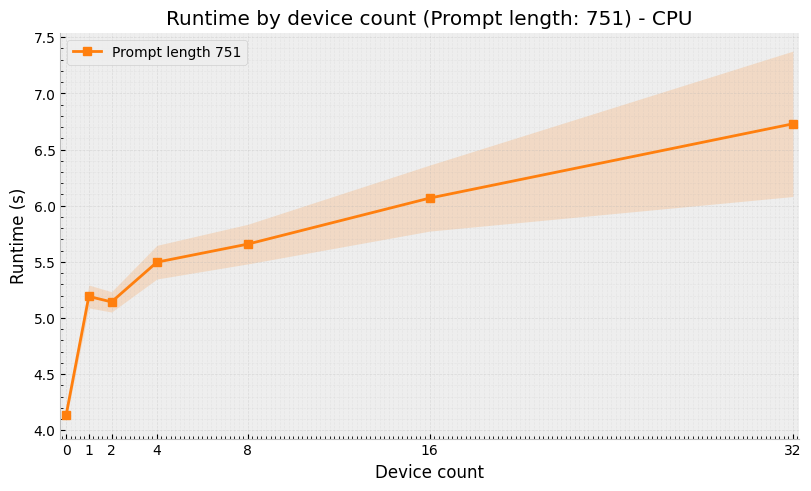

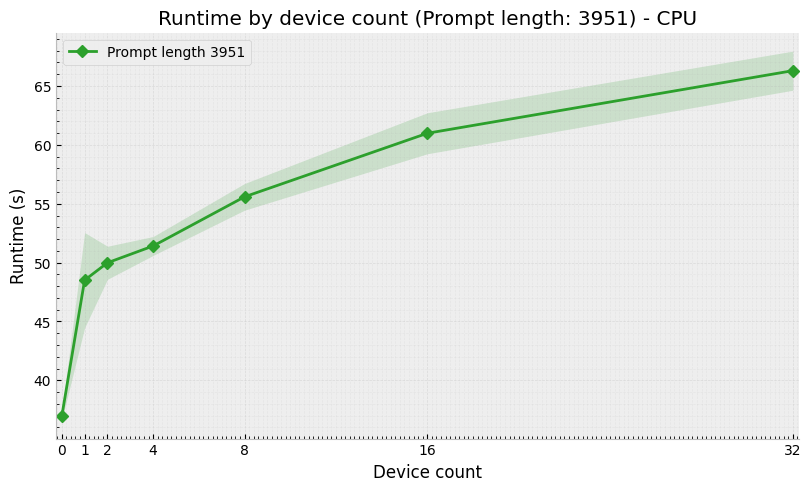

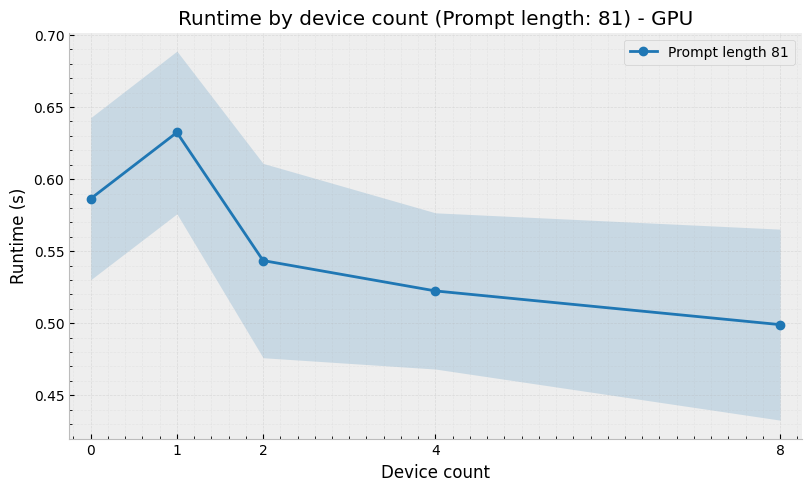

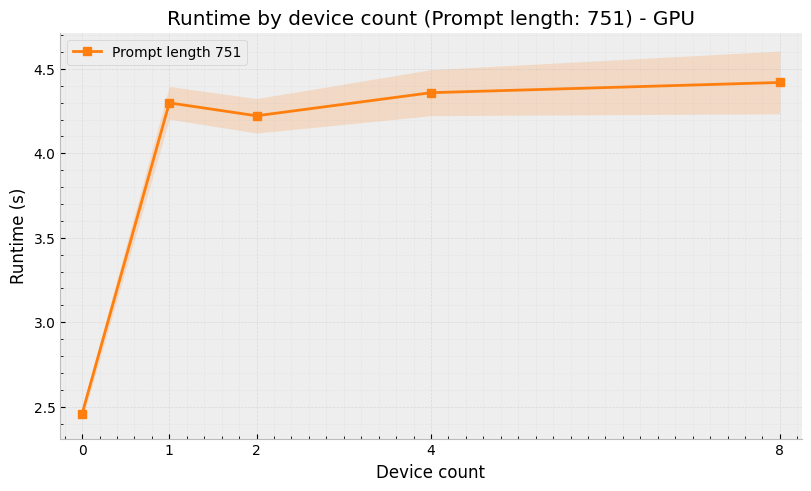

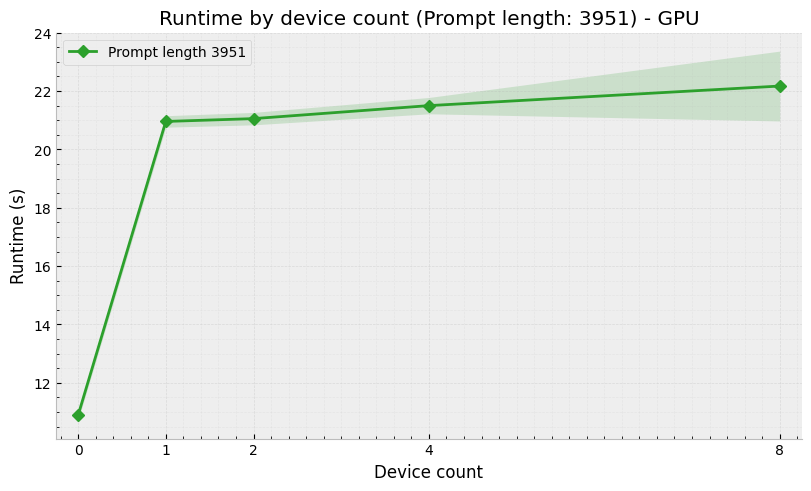

In [4]:
runtime_by_device_count(data[data["device_type"] == "cpu"], title="CPU")
runtime_by_device_count(data[data["device_type"] == "gpu"], title="GPU")

In [5]:
def dot_plot_by_prompt_length(df: pd.DataFrame) -> None:
    # Map device_count to uniform positions
    stats = (
        df.groupby(["prompt_length", "device_count"], as_index=False)["time"]
            .agg(mean="mean", std="std")
    )
    stats["std"] = stats["std"].fillna(0.0)

    cmap = plt.get_cmap("tab10")
    markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]
    xticks = sorted(stats["device_count"].unique())
    uniform_positions = {dc: i for i, dc in enumerate(xticks)}

    plt.style.use("bmh")
    lengths = list(stats["prompt_length"].unique())
    colors = [cmap(i % 10) for i in range(len(lengths))]

    nrows = int(len(lengths))
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 4.5 * nrows), constrained_layout=True)
    axes = axes.flatten() if len(lengths) > 1 else [axes]

    for idx, length in enumerate(lengths):
        ax = axes[idx]
        d = df[df["prompt_length"] == length]
        # Map device_count to uniform positions
        x = d["device_count"].map(uniform_positions)
        ax.scatter(
            x,
            d["time"],
            s=22,
            alpha=0.2,
            color=colors[idx],
            marker=markers[idx % len(markers)],
            edgecolor="white",
            linewidth=0.4,
            label="Runs",
        )

        positions = sorted(d["device_count"].unique())
        xd = [d.loc[d["device_count"] == dc, "time"] for dc in positions]
        box_positions = [uniform_positions[p] + 0.1 for p in positions]

        bp = ax.boxplot(
            xd,
            positions=box_positions,
            widths=0.05,
            patch_artist=True,
            boxprops=dict(facecolor=colors[idx], alpha=0.4),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(color=colors[idx]),
            capprops=dict(color=colors[idx]),
            flierprops=dict(marker="o", markerfacecolor="gray", alpha=0.4, markersize=3),
        )

        ax.set_xticks(list(uniform_positions.values()))
        ax.set_xticklabels([str(int(p)) for p in xticks])
        ax.set_xlim(-0.6, len(xticks) - 0.4)
        ax.set_xlabel("Device count")
        ax.set_ylabel("Runtime (s)")
        ax.set_title(f"Prompt length: {length}")
        ax.grid(which="major", alpha=0.5)
        ax.minorticks_off()
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.legend(frameon=True, fancybox=True, framealpha=0.9, loc="best")

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Runtime distribution by device count (uniform x-axis spacing)", fontsize=16, y=1.02)
    plt.show()


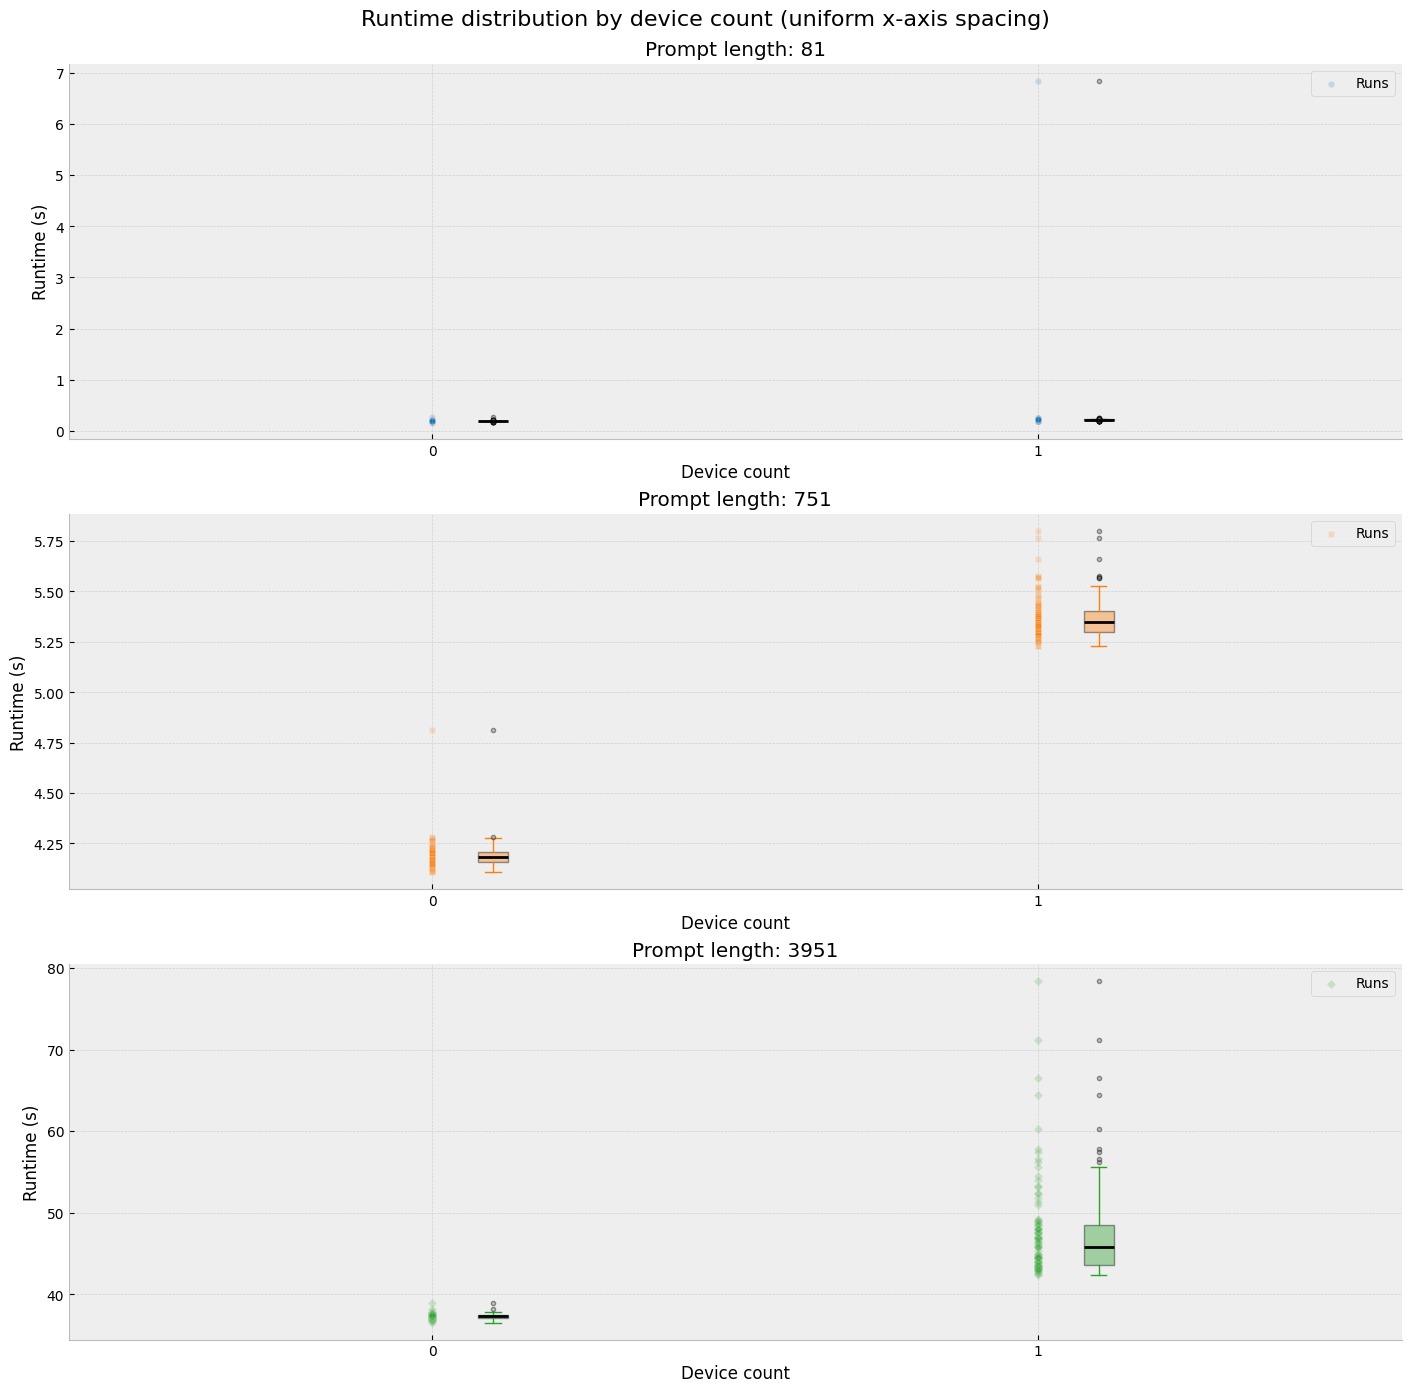

In [6]:
dot_plot_by_prompt_length(data[data["device_type"] == "cpu_100"])

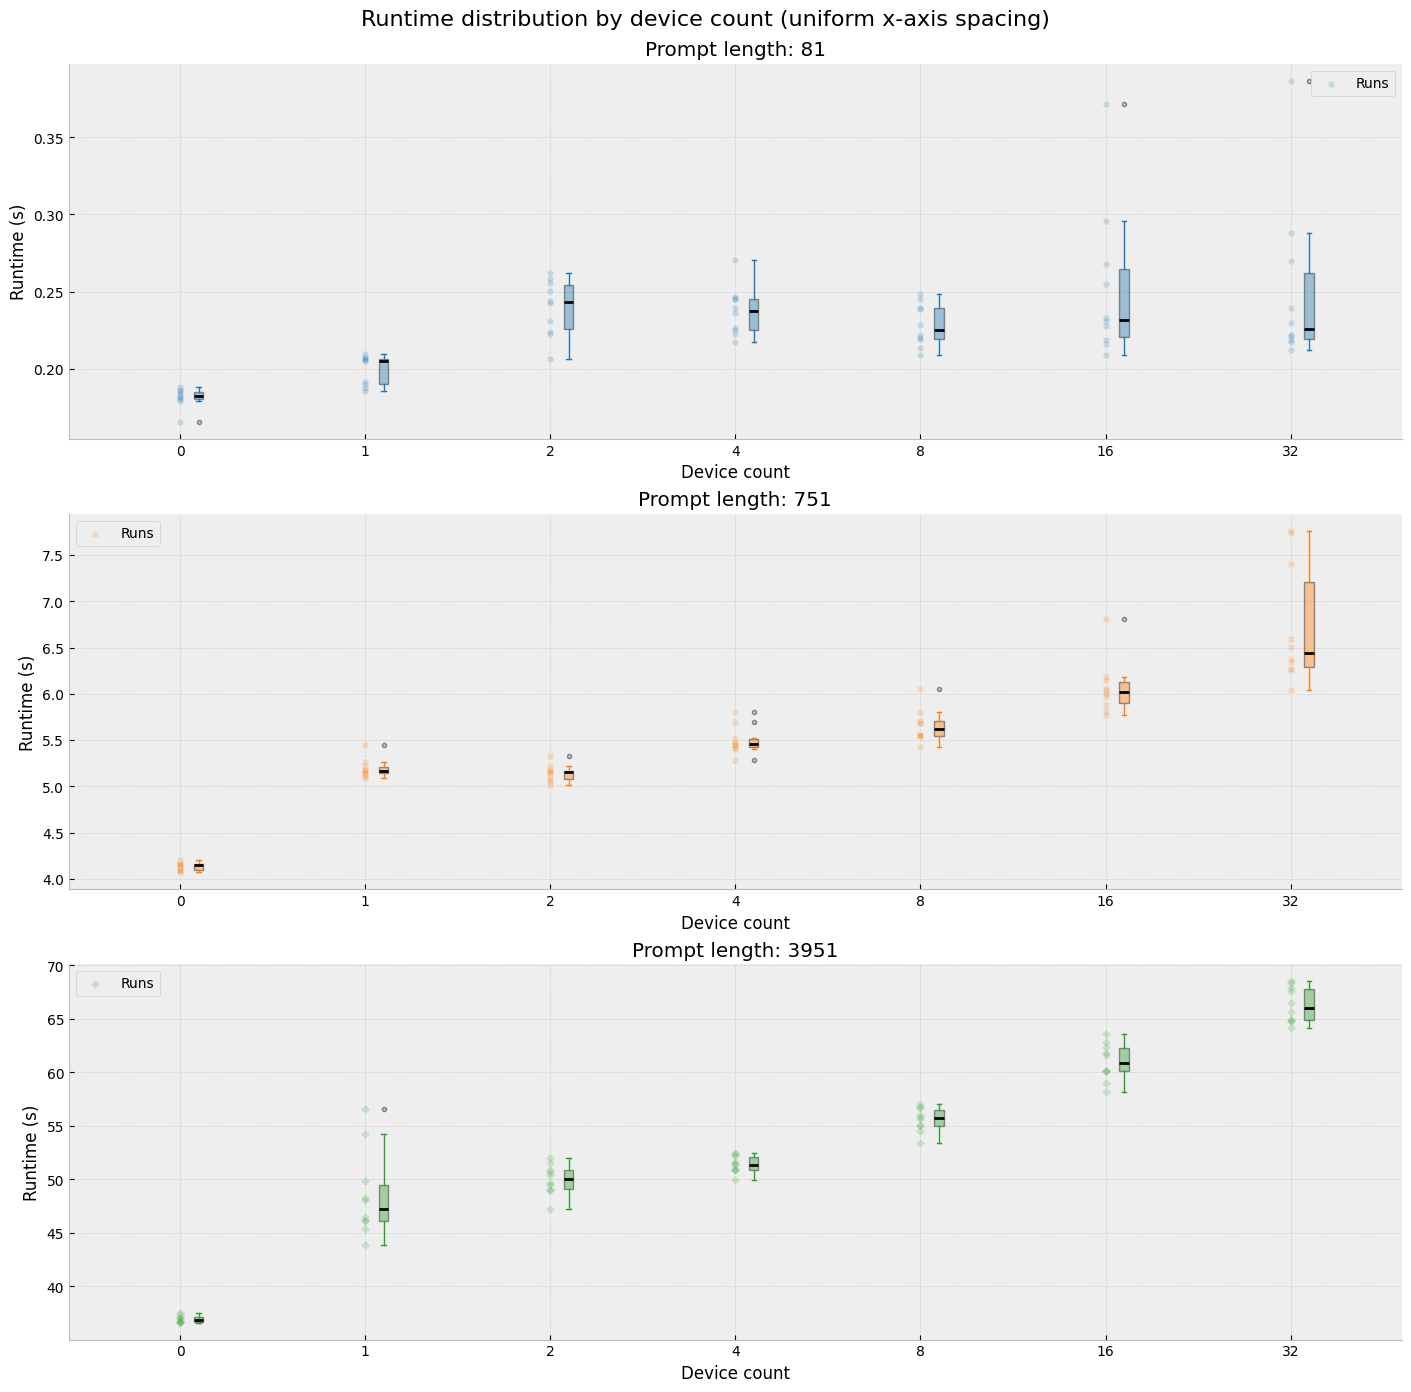

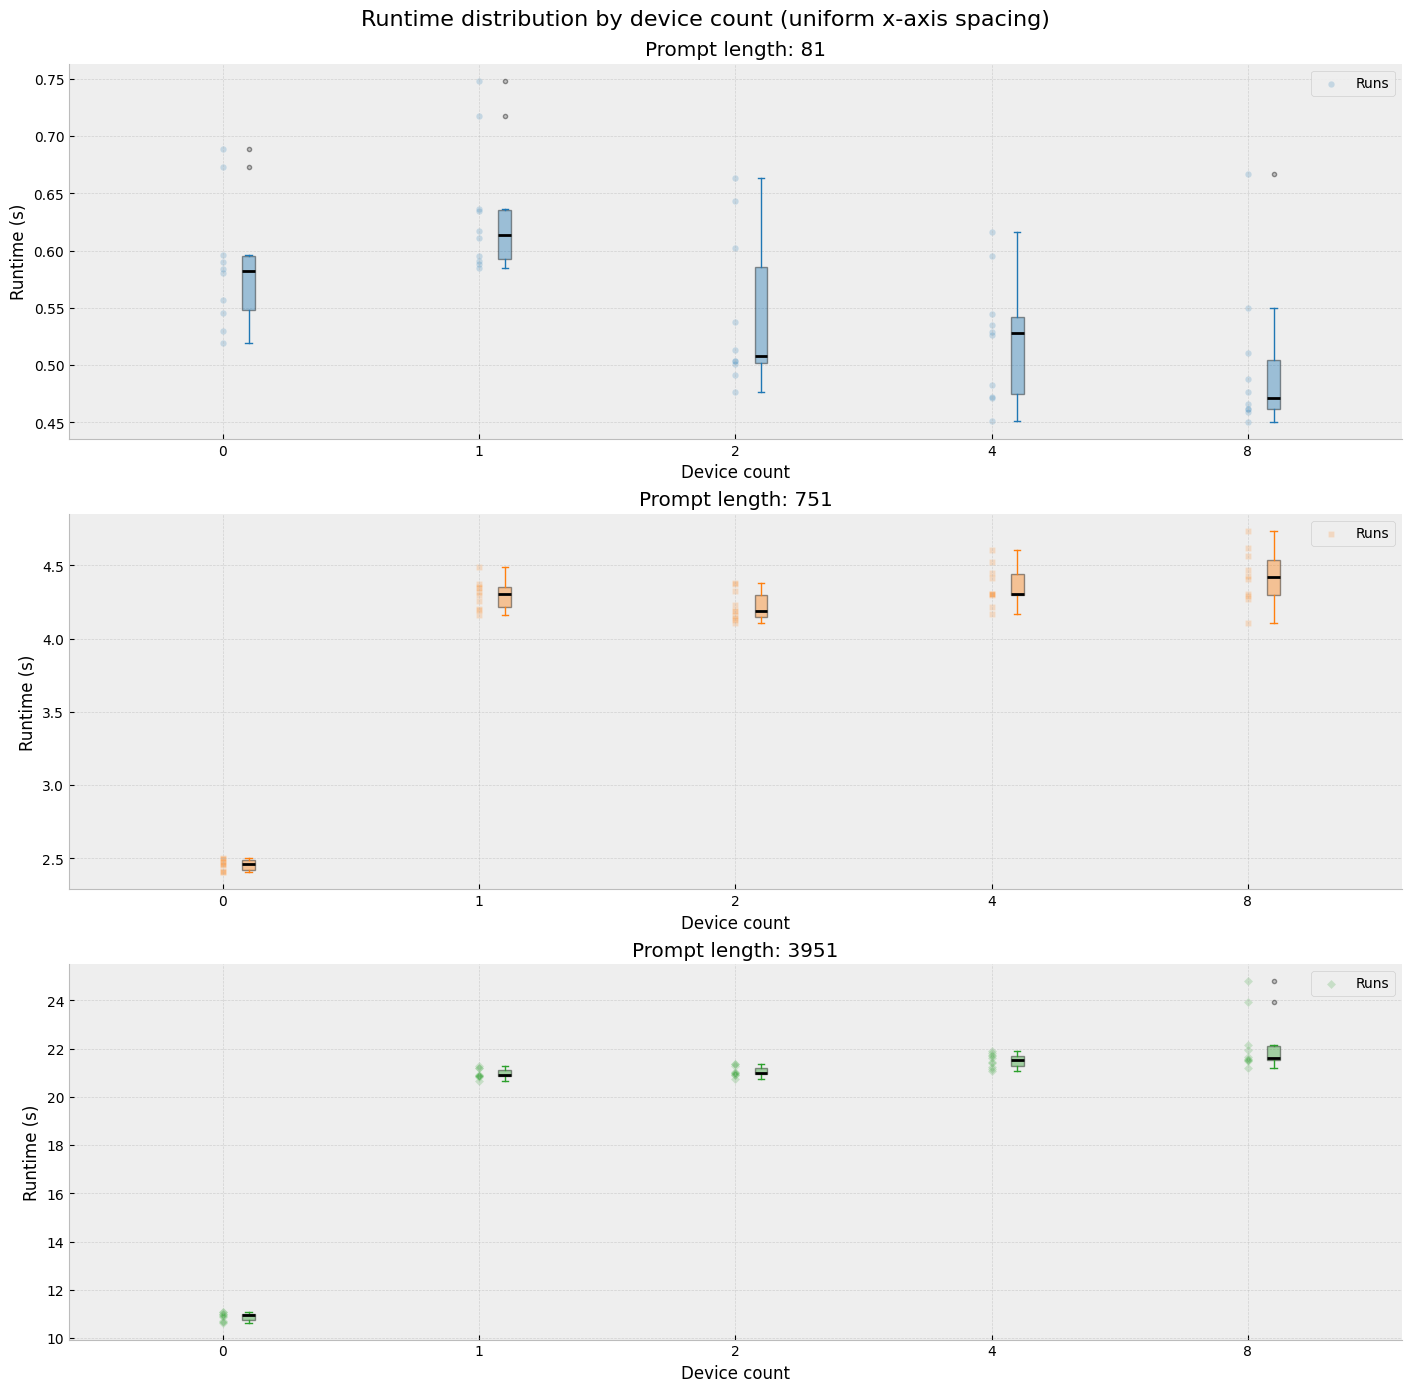

In [7]:
dot_plot_by_prompt_length(data[data["device_type"] == "cpu"])
dot_plot_by_prompt_length(data[data["device_type"] == "gpu"])